Initial Data Exploration
Load the dataset using Pandas. Check for null values and understand data types.
Examine the time series properties of the data (e.g., frequency, trends).


Data Visualization
Utilize Matplotlib to plot closing prices and traded volume over time.
Create a candlestick chart to depict high and low prices.


In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [85]:
df=pd.read_csv('Apple Stock Prices (1981 to 2023).csv')
df.head(20)

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200
5,09/01/1981,0.142299,0.142857,0.142299,0.142299,0.110730,21504000
6,12/01/1981,0.142299,0.142299,0.141183,0.141183,0.109861,23699200
7,13/01/1981,0.136719,0.136719,0.136161,0.136161,0.105953,23049600
8,14/01/1981,0.136719,0.137277,0.136719,0.136719,0.106388,14291200
9,15/01/1981,0.139509,0.140625,0.139509,0.139509,0.108559,14067200


In [86]:
print(df.shape)
df.info()

(10608, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  object 
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 580.2+ KB


In [87]:

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)


In [104]:
df['Date'].unique()

<DatetimeArray>
['1981-01-02 00:00:00', '1981-01-05 00:00:00', '1981-01-06 00:00:00',
 '1981-01-07 00:00:00', '1981-01-08 00:00:00', '1981-01-09 00:00:00',
 '1981-01-12 00:00:00', '1981-01-13 00:00:00', '1981-01-14 00:00:00',
 '1981-01-15 00:00:00',
 ...
 '2023-01-13 00:00:00', '2023-01-17 00:00:00', '2023-01-18 00:00:00',
 '2023-01-19 00:00:00', '2023-01-20 00:00:00', '2023-01-23 00:00:00',
 '2023-01-24 00:00:00', '2023-01-25 00:00:00', '2023-01-26 00:00:00',
 '2023-01-27 00:00:00']
Length: 10608, dtype: datetime64[ns]

from the df['Date'] shows that, weekends were not included in data.

In [88]:
#checking for trends in the data
first_price = df['Close'].iloc[0]
last_price = df['Close'].iloc[-1]   
total_return = ((last_price - first_price) / first_price )* 100
total_growth = (last_price / first_price) * 100
print(f"Total Return: {total_return:.2f}%")
print(f"Total Growth: {total_growth:.2f}%")


Total Return: 94648.66%
Total Growth: 94748.66%


In [89]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,10608,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,2002-01-05 14:08:33.122171904,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
min,1981-01-02 00:00:00,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,1991-06-27 18:00:00,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08
50%,2002-01-02 12:00:00,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
75%,2012-07-13 18:00:00,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08
max,2023-01-27 00:00:00,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09
std,NaN,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08


In [90]:
df.isna().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

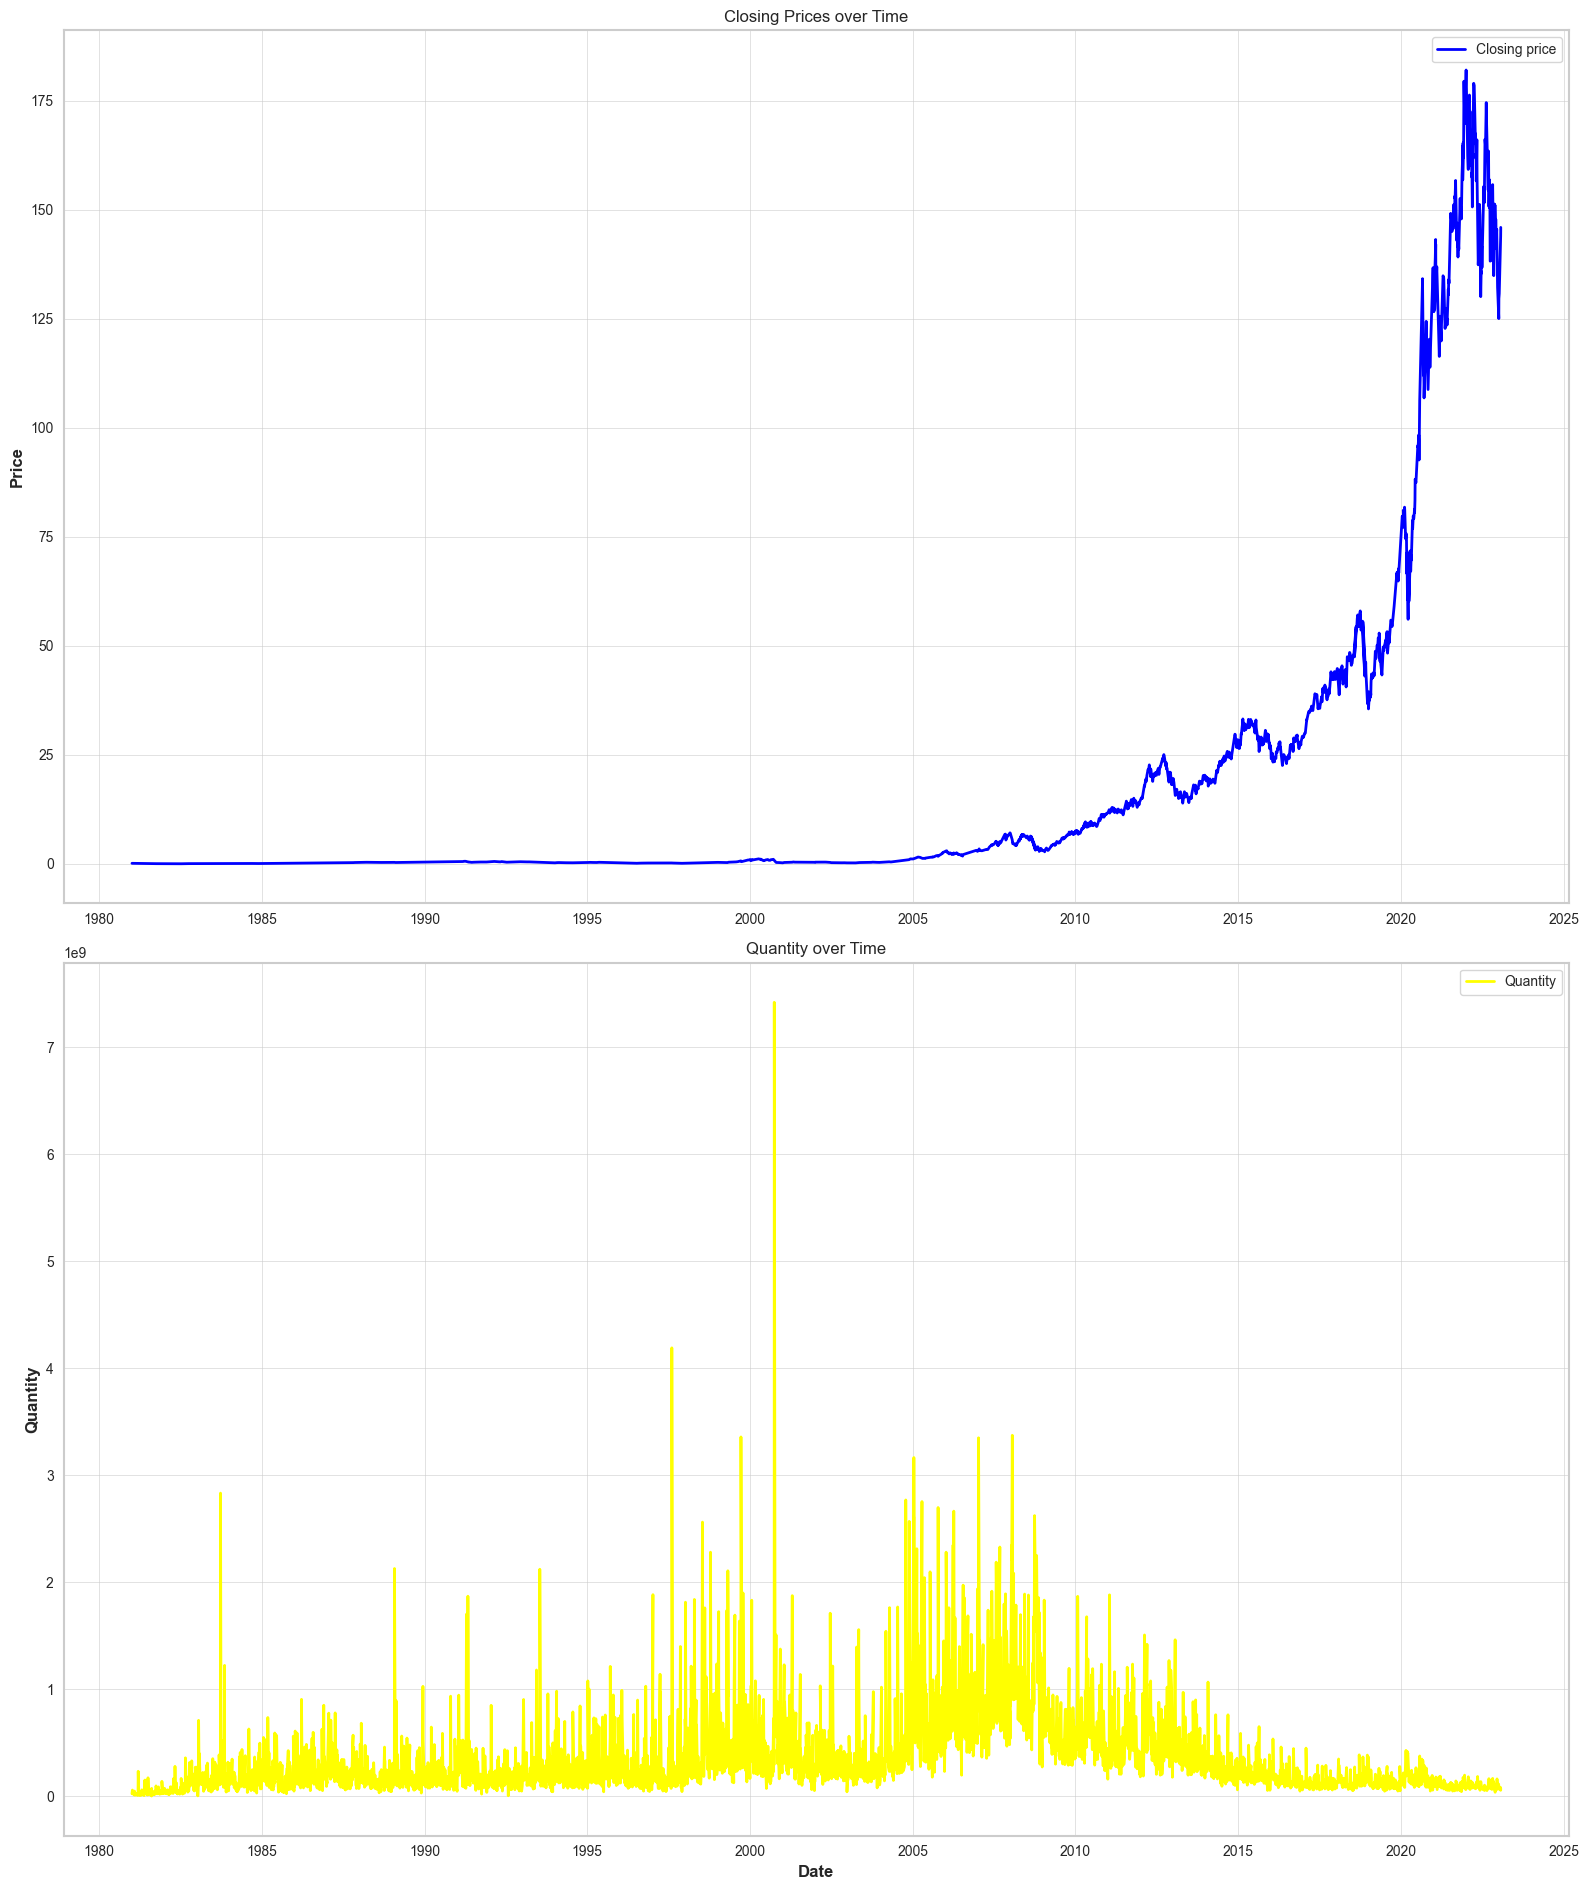

In [91]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 19))
ax1.plot(df['Date'], df['Close'], color='blue', label='Closing price')
ax1.set_title('Closing Prices over Time')
ax1.set_ylabel('Price')
ax1.legend()

ax2.plot(df['Date'], df['Volume'], color='yellow', label='Quantity')
ax2.set_title('Quantity over Time')
ax2.set_xlabel('Date')
ax2.set_ylabel('Quantity')
ax2.legend()

plt.tight_layout()
plt.show()

In [92]:

df['Year'] = df['Date'].dt.year
df_yearly = df.groupby('Year').agg({'Close': 'mean', 'Volume': 'mean'}).reset_index()

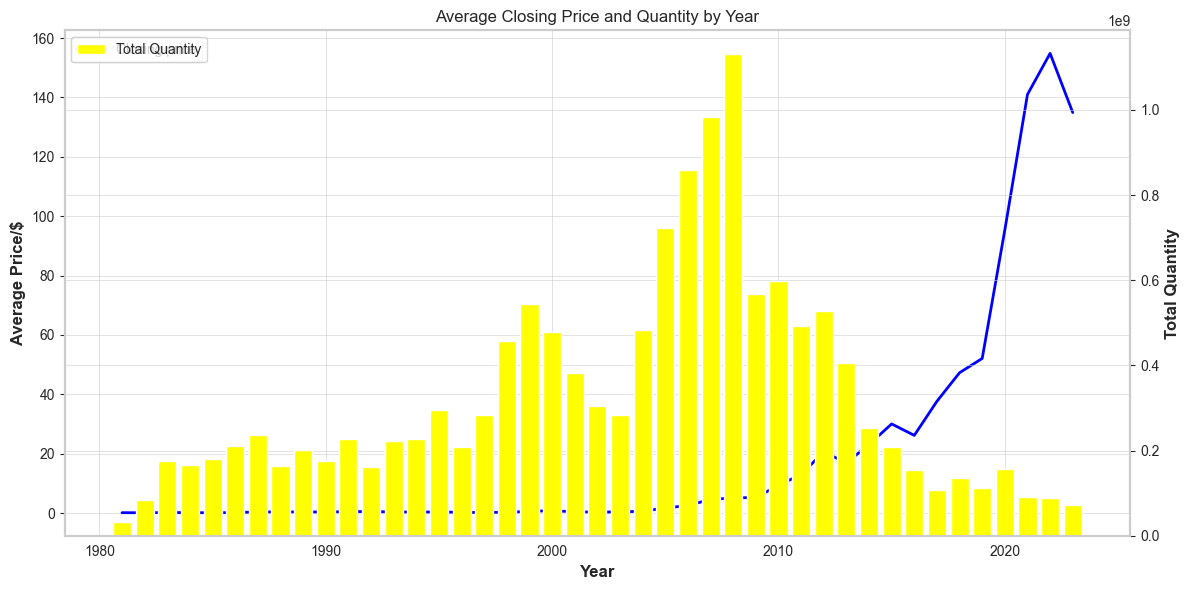

In [93]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_yearly['Year'], df_yearly['Close'], color='blue', label='Closing price')
ax.set_xlabel('Year')
ax.set_ylabel('Average Price/$')
ax.legend()
ax1=ax.twinx()
ax1.bar(df_yearly['Year'], df_yearly['Volume'], color='yellow', label='Total Quantity')    
ax1.set_ylabel('Total Quantity')
ax1.legend(loc='upper left')  
plt.title('Average Closing Price and Quantity by Year')      
plt.tight_layout()
plt.show()

In [94]:
%pip install mplfinance
import mplfinance as mpf


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Program Files (x86)\Microsoft Visual Studio\Shared\Python39_64\python.exe -m pip install --upgrade pip' command.


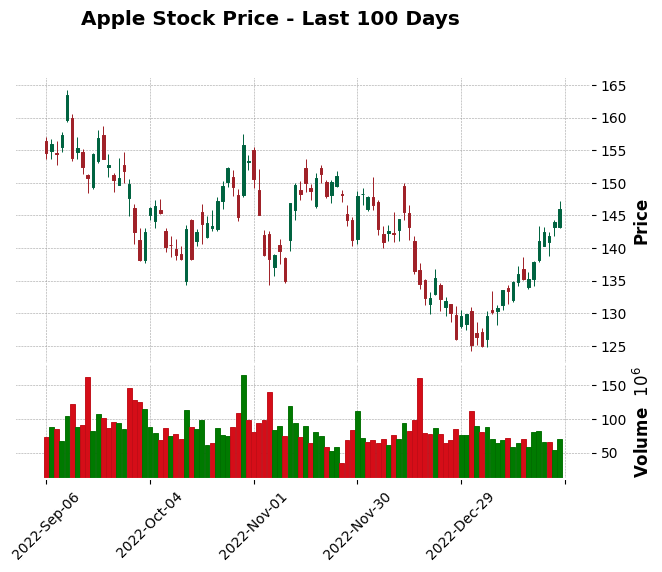

In [95]:
data_slice=df.tail(100)
data_slice.set_index('Date', inplace=True)
mpf.plot(data_slice, type='candle', style='charles', volume=True, title='Apple Stock Price - Last 100 Days')


The visualization reveals that  trading volume peaked during the middle and getting to the late of September, then in the middle of November.The price auction in December was dominated by bearish sentiment with a high volume of sales. Price began to consolidate in January after a high dip in December with buyers stepping in to increase the closing prices from $125 to almost $150


Statistical Analysis
Compute summary statistics (mean, median, standard deviation) for key columns.
Analyze closing prices with a moving average.


Hypothesis Testing
Execute a t-test to compare average closing prices across different years.
Examine daily returns’ distribution and test for normality using SciPy.



In [96]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Year'], dtype='object')

In [97]:
df_stats = df[['Open', 'High', 'Low', 'Close', 'Volume']].agg(['mean', 'median', 'std'])
print(df_stats)

             Open       High        Low      Close        Volume
mean    16.689173  16.879955  16.500822  16.697362  3.275098e+08
median   0.488839   0.495536   0.480446   0.487701  2.145976e+08
std     35.450519  35.882848  35.031289  35.473912  3.378203e+08


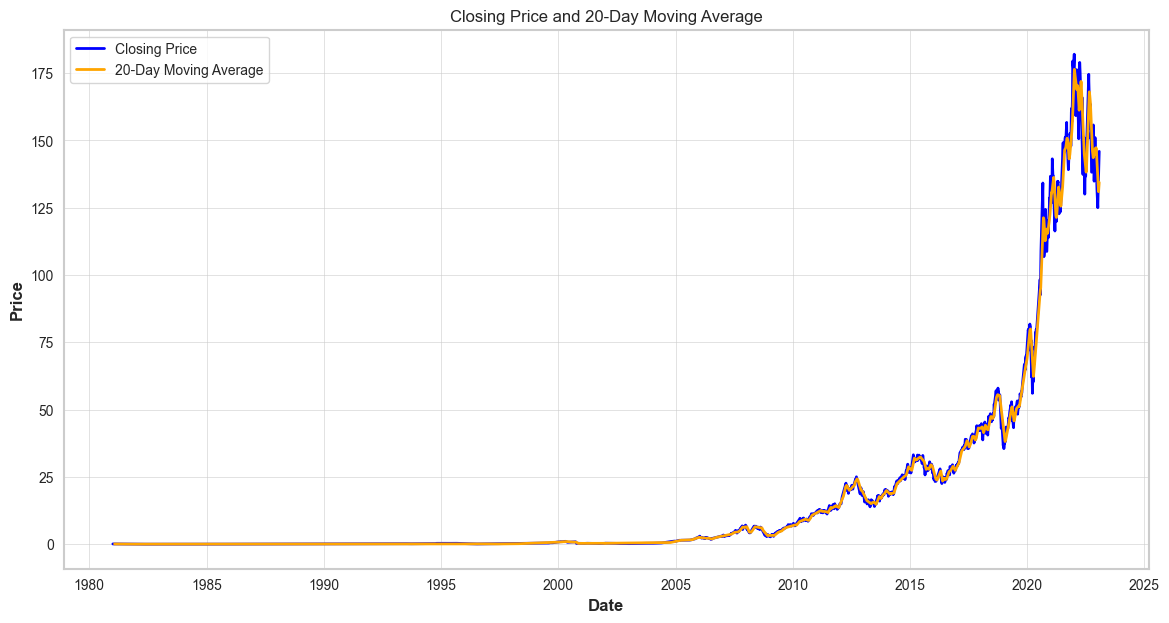

In [98]:
df['Move_avg_20'] = df['Close'].rolling(window=20).mean()
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7)) 
plt.plot(df['Date'], df['Close'], label='Closing Price', color='blue')
plt.plot(df['Date'], df['Move_avg_20'], label='20-Day Moving Average', color='orange')
plt.title('Closing Price and 20-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

from the time series gragh, from 1980 to around 2007, the price levels were insignificant compared to today's price. And the years between 2020, price grew more higher with higher price volatility.

In [99]:
from scipy.stats import pearsonr, spearmanr, kendalltau, f_oneway, chi2_contingency,ttest_ind,shapiro

In [100]:
close_2020 = df[df['Year'] == 2020]['Close'].values
close_2021 = df[df['Year'] == 2021]['Close'].values
t_stat, p_value = ttest_ind(close_2020, close_2021)
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.2f}")
message = "There is a significant difference in closing prices between 2020 and 2021." if p_value < 0.05 else "There is no significant difference in closing prices between 2020 and 2021."
print(message)

T-statistic: -27.59, P-value: 0.00
There is a significant difference in closing prices between 2020 and 2021.


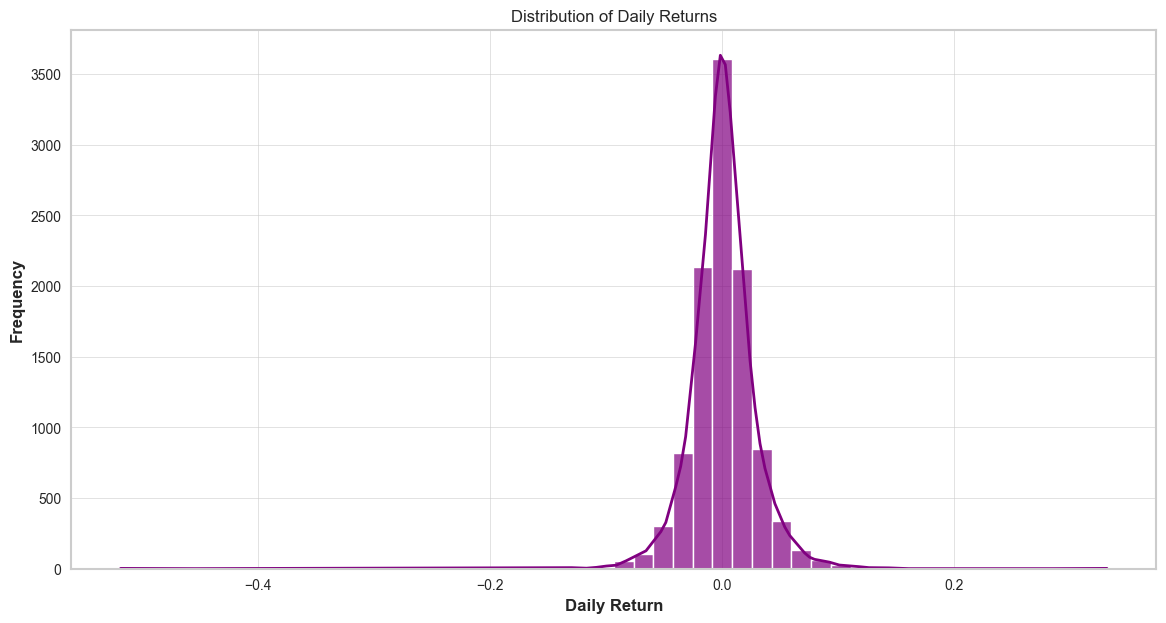

In [101]:
df['Daily_Return'] = df['Close'].pct_change()
plt.figure(figsize=(14, 7)) 
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True, color='purple', alpha=0.7)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')  
plt.ylabel('Frequency')
plt.show()



In [102]:
stat, p_value = shapiro(df['Daily_Return'].dropna())
print(f"Shapiro-Wilk Test: Statistic={stat:.4f}, P-value={p_value:.4f}")
message = "The daily returns are normally distributed." if p_value > 0.05 else "The daily returns are not normally distributed."
print(message)

Shapiro-Wilk Test: Statistic=0.9191, P-value=0.0000
The daily returns are not normally distributed.


C:\Users\njedr\AppData\Roaming\Python\Python39\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10607.
  res = hypotest_fun_out(*samples, **kwds)



Advanced Statistical Techniques (Bonus)
Statistical Functions in NumPy: Employ NumPy’s statistical functions for in-depth stock data analysis.
E.g., Use convolve for moving averages, or np.corrcoef to explore correlations between financial metrics.
Analyze correlations between moving averages of closing prices and trading volume across time periods.


In [103]:
df['move_avg__price50'] = df['Close'].rolling(window=50).mean()
df['move_avg__volume50'] = df['Volume'].rolling(window=50).mean()
clean_data = df.dropna(subset=['move_avg__price50', 'move_avg__volume50'])
correlation_matrix = np.corrcoef(clean_data['move_avg__price50'], clean_data['move_avg__volume50'])
correlation = correlation_matrix[0, 1]
print(f"The correlation between the 50-day moving average of price and volume is {correlation:.2f}.")





The correlation between the 50-day moving average of price and volume is -0.28.


The correlation value shows that there is a negative relation between average prices and volume, thats the higher the price, the less quantity demanded.

<!-- Project Summary: Time-Series Analysis of Apple Inc. (AAPL) -->
1. Exploratory Data Analysis & Performance Metrics
We initiated the project by quantifying the long-term value creation of the asset. By leveraging Python’s iloc for precise data slicing, we calculated two distinct but related metrics:
• Total Return (~94,648%): This represents the net profit percentage. It accounts for the capital gains relative to the initial investment cost.
• Total Growth (~94,748%): This represents the gross multiplier. The 100% variance between these two figures is the mathematical representation of the initial principal investment (\bm{Growth = Return + 100\%}).
• Data Integrity: A manual audit of the df['Date].unique() confirmed that the time series correctly excludes non-trading days (weekends and market holidays), ensuring that volatility calculations are not skewed by "empty" time steps.
2. Advanced Visualization & Market Microstructure
Using the mplfinance library, we shifted from a global macro view to a 100-day micro-analysis (Sept 2022 – Jan 2023) using OHLC Candlestick and Volume charts.
• Candlestick Interpretation: We analyzed the "battle for price" through candle bodies. Green candles signaled days where buying conviction (Demand) outweighed selling pressure (Supply), while Red candles signaled the opposite.
• Price Rejection & Wicks: We identified long lower wicks during the late December period. Statistically, these represent price rejection at lower levels, indicating that the market found a "support floor" near $125.
3. Volume-Price Dynamics
The integration of a Volume subplot allowed for an analysis of Market Conviction:
• High-Volume Confirmation: We observed that the sharpest price declines in November were accompanied by significant volume spikes. This confirms "High Conviction" selling (Supply-driven volatility).
• Consolidation & Reversal: In late December, we noted a period of price consolidation followed by a "V-shaped" recovery. As buyers stepped back in, the price rose from $125 to nearly $150, marking a clear trend reversal supported by shifting participant willingness.
4. Statistical Properties of the Time Series
The preliminary statistical scan using df.describe() provided the following insights into the asset's distribution:
• Volatility (\bm{\sigma}): The standard deviation serves as our primary proxy for risk. The wide "spread" (High - Low) observed in the candlesticks correlates with a high standard deviation, reflecting Apple's historical price swings.
• Skewness: Given the massive growth from 1981 to 2023, the data exhibits a strong positive skew, where the mean is significantly influenced by the exponential price increases in the latter half of the dataset.

<!-- . Conclusion -->
The analysis demonstrates that while Apple has provided extraordinary long-term Growth, it is subject to significant periodic Volatility. The late 2022 data specifically highlights how technical "Support Levels" and "Trading Volume" can be used to identify trend exhaustion and subsequent market recovery.

Major challenges:
The major challenge was trying to understand how the Mlf chart works, with the help of ChatGPT  and Gemini, I got the basic understanding on how it works and its interpretaions.